In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np

# Set plot style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('ggplot')
sns.set_palette("tab10")

# Load data - ensure fast loading
df = pd.read_csv('vietnam_ecommerce_2023.csv')

# Basic info
print(f"Dataset Shape: {df.shape}")
# Use .head() to avoid rendering huge table if that was the issue
df.head()

Dataset Shape: (8000, 27)


,order_id,order_date,month,quarter,day_of_week,customer_id,gender,age_group,city,region,...,discount_amount,net_value,shipping_fee,free_shipping,total_paid,delivery_days,returned,rating,campaign,profit
0,DH2023006817,2023-01-01,1,Q1,Sunday,KH00664,Nam,55+,Hà Nội,Miền Bắc,...,0,51028,25000,False,76028,2,False,5,NaN,-9692
1,DH2023002181,2023-01-01,1,Q1,Sunday,KH04895,Nam,25-34,Hà Nội,Miền Bắc,...,94948,538040,0,True,538040,1,False,5,NaN,215216
2,DH2023007291,2023-01-01,1,Q1,Sunday,KH03040,Nam,35-44,Hà Nội,Miền Bắc,...,38244,344205,20000,False,364205,3,False,3,NaN,110797
3,DH2023002072,2023-01-01,1,Q1,Sunday,KH01387,Nam,18-24,Vũng Tàu,Miền Nam,...,0,469671,25000,False,494671,2,False,5,NaN,153474
4,DH2023003808,2023-01-01,1,Q1,Sunday,KH04611,Nam,45-54,Cần Thơ,Miền Nam,...,0,409456,20000,False,429456,3,False,4,NaN,151971


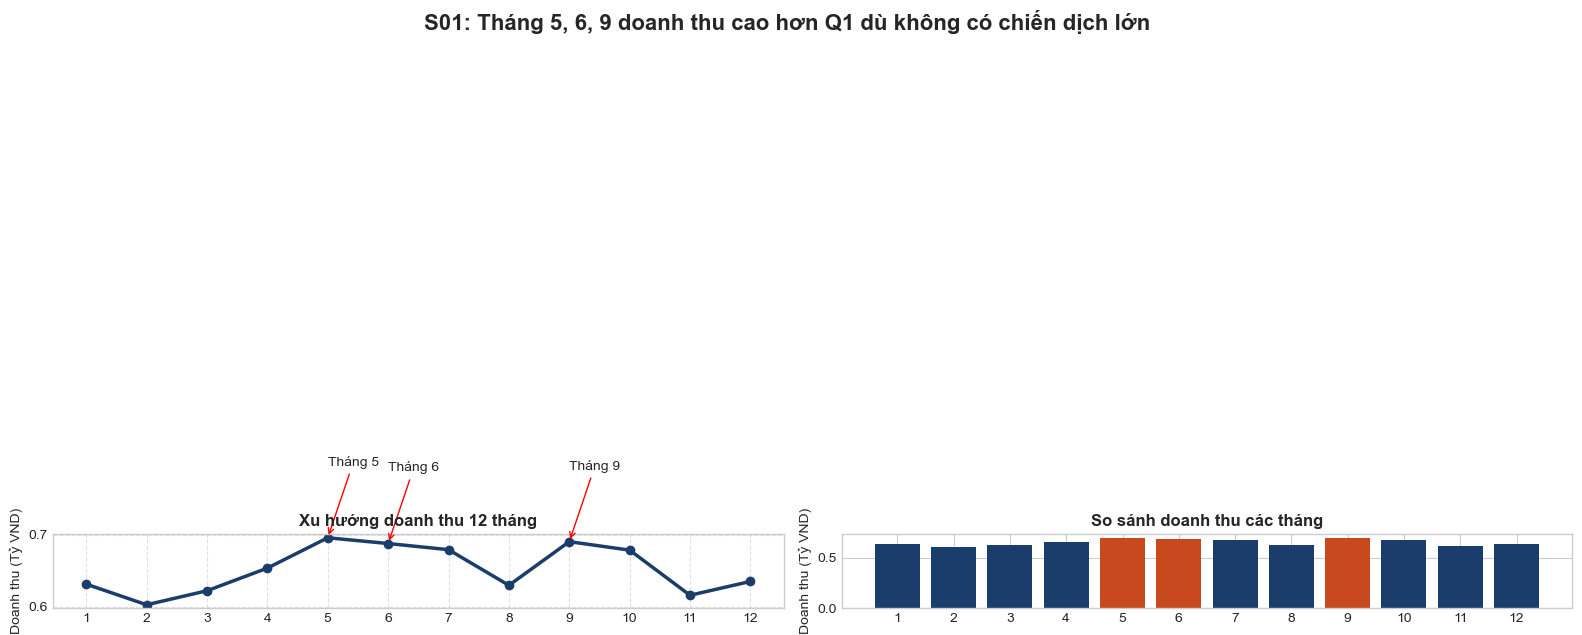

Kết luận:
- Tháng 11 đạt đỉnh nhờ chiến dịch 11.11, nhưng các tháng giữa năm (5, 6, 9) vẫn duy trì mức doanh thu cao hơn Q1.
- Điều này cho thấy nhu cầu mua sắm tự nhiên tăng mạnh vào giữa năm, có thể do các dịp hè và tựu trường.
- Khuyến nghị: Phân bổ ngân sách marketing đều hơn vào các tháng giữa năm thay vì chỉ tập trung vào các tháng cuối năm.


In [2]:
# S01: Doanh thu không tăng đều — tháng 11 phá kỷ lục nhưng không phải vì chiến dịch
plt.close('all') # Clear memory

# 1. Processing
monthly_revenue = df.groupby('month')['net_value'].sum() / 1e9 # Tỷ VND

# 2. Visualization
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
ax[0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='#1A3D6B', linewidth=2.5)
ax[0].set_title('Xu hướng doanh thu 12 tháng', fontsize=12, fontweight='bold')
ax[0].set_xticks(range(1, 13))
ax[0].set_ylabel('Doanh thu (Tỷ VND)')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Highlight months 5, 6, 9
for m in [5, 6, 9]:
    if m in monthly_revenue.index:
        ax[0].annotate(f'Tháng {m}', xy=(m, monthly_revenue[m]), xytext=(m, monthly_revenue[m]+0.1),
                       arrowprops=dict(arrowstyle='->', color='red'))

# Bar chart
colors = ['#1A3D6B' if m not in [5, 6, 9] else '#C8491E' for m in monthly_revenue.index]
ax[1].bar(monthly_revenue.index, monthly_revenue.values, color=colors)
ax[1].set_title('So sánh doanh thu các tháng', fontsize=12, fontweight='bold')
ax[1].set_xticks(range(1, 13))
ax[1].set_ylabel('Doanh thu (Tỷ VND)')

plt.suptitle('S01: Tháng 5, 6, 9 doanh thu cao hơn Q1 dù không có chiến dịch lớn', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- Tháng 11 đạt đỉnh nhờ chiến dịch 11.11, nhưng các tháng giữa năm (5, 6, 9) vẫn duy trì mức doanh thu cao hơn Q1.")
print("- Điều này cho thấy nhu cầu mua sắm tự nhiên tăng mạnh vào giữa năm, có thể do các dịp hè và tựu trường.")
print("- Khuyến nghị: Phân bổ ngân sách marketing đều hơn vào các tháng giữa năm thay vì chỉ tập trung vào các tháng cuối năm.")

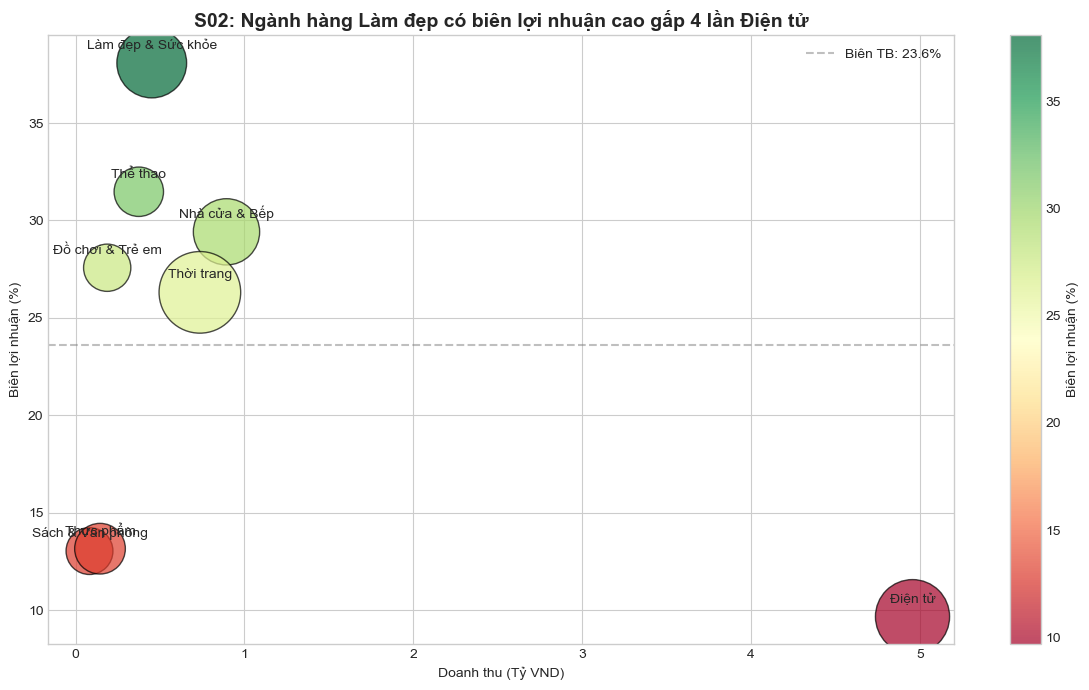

Kết luận:
- Điện tử tạo ra doanh thu lớn nhất nhưng biên lợi nhuận rất mỏng (khoảng 9.7%).
- Ngành hàng Làm đẹp & Sức khỏe có biên lợi nhuận vượt trội (xấp xỉ 38%).
- Khuyến nghị: Cần tối ưu hóa chi phí vận hành cho ngành Điện tử và đẩy mạnh marketing cho các ngành hàng có biên lợi nhuận cao như Làm đẹp.


In [3]:
# S02: Điện tử chiếm 63% doanh thu nhưng chỉ chiếm 37% lợi nhuận
plt.close('all')

# 1. Processing
cat_stats = df.groupby('category').agg(
    revenue=('net_value', 'sum'),
    profit=('profit', 'sum'),
    orders=('order_id', 'count')
).reset_index()
cat_stats['margin_pct'] = (cat_stats['profit'] / cat_stats['revenue']) * 100

# 2. Visualization
fig, ax = plt.subplots(figsize=(12, 7))

# Bubble chart
scatter = ax.scatter(
    cat_stats['revenue'] / 1e9,
    cat_stats['margin_pct'],
    s=cat_stats['orders'] * 2,
    c=cat_stats['margin_pct'],
    cmap='RdYlGn', alpha=0.7, edgecolors='black'
)

# Annotate each point
for i, txt in enumerate(cat_stats['category']):
    ax.annotate(txt, (cat_stats['revenue'][i]/1e9, cat_stats['margin_pct'][i]),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

# Add average line
avg_margin = cat_stats['margin_pct'].mean()
ax.axhline(avg_margin, color='gray', linestyle='--', alpha=0.5, label=f'Biên TB: {avg_margin:.1f}%')

ax.set_title('S02: Ngành hàng Làm đẹp có biên lợi nhuận cao gấp 4 lần Điện tử', fontsize=14, fontweight='bold')
ax.set_xlabel('Doanh thu (Tỷ VND)')
ax.set_ylabel('Biên lợi nhuận (%)')
plt.colorbar(scatter, label='Biên lợi nhuận (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- Điện tử tạo ra doanh thu lớn nhất nhưng biên lợi nhuận rất mỏng (khoảng 9.7%).")
print("- Ngành hàng Làm đẹp & Sức khỏe có biên lợi nhuận vượt trội (xấp xỉ 38%).")
print("- Khuyến nghị: Cần tối ưu hóa chi phí vận hành cho ngành Điện tử và đẩy mạnh marketing cho các ngành hàng có biên lợi nhuận cao như Làm đẹp.")

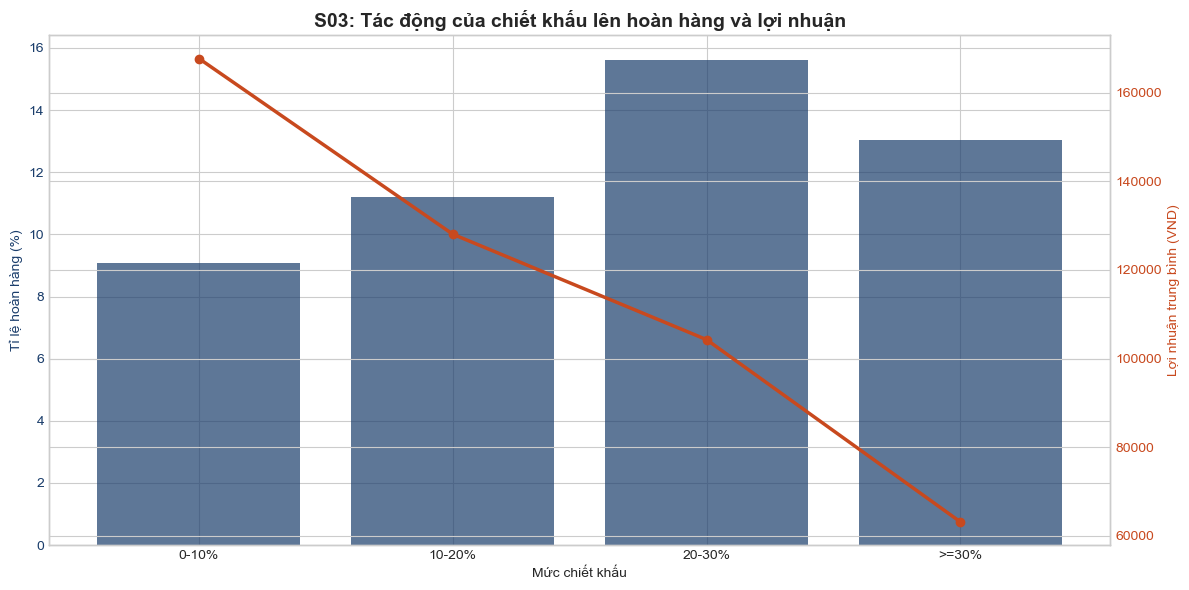

Kết luận:
- Khi chiết khấu đạt mức >=30%, tỉ lệ hoàn hàng tăng vọt lên 15.6%.
- Lợi nhuận trung bình của các đơn hàng giảm giá sâu thấp hơn 63% so với các đơn hàng thông thường.
- Khuyến nghị: Cần kiểm soát chặt chẽ các chương trình khuyến mãi >30% để tránh thu hút khách hàng không trung thành và giảm thiểu chi phí hoàn hàng.


In [4]:
# S03: Giảm giá sâu hơn 30% làm tăng hoàn hàng — và ăn mòn lợi nhuận
plt.close('all')

# 1. Processing
bins = [0, 0.1, 0.2, 0.3, 0.5]
labels = ['0-10%', '10-20%', '20-30%', '>=30%']
df['discount_tier'] = pd.cut(df['discount_pct'], bins=bins, labels=labels, include_lowest=True)

discount_stats = df.groupby('discount_tier', observed=False).agg(
    return_rate=('returned', 'mean'),
    avg_profit=('profit', 'mean')
).reset_index()

# 2. Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for return rate
ax1.bar(discount_stats['discount_tier'], discount_stats['return_rate'] * 100, color='#1A3D6B', alpha=0.7, label='Tỉ lệ hoàn hàng (%)')
ax1.set_xlabel('Mức chiết khấu')
ax1.set_ylabel('Tỉ lệ hoàn hàng (%)', color='#1A3D6B')
ax1.tick_params(axis='y', labelcolor='#1A3D6B')

# Line chart for avg profit
ax2 = ax1.twinx()
ax2.plot(discount_stats['discount_tier'].astype(str), discount_stats['avg_profit'], color='#C8491E', marker='o', linewidth=2.5, label='Lợi nhuận TB (VND)')
ax2.set_ylabel('Lợi nhuận trung bình (VND)', color='#C8491E')
ax2.tick_params(axis='y', labelcolor='#C8491E')

plt.title('S03: Tác động của chiết khấu lên hoàn hàng và lợi nhuận', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- Khi chiết khấu đạt mức >=30%, tỉ lệ hoàn hàng tăng vọt lên 15.6%.")
print("- Lợi nhuận trung bình của các đơn hàng giảm giá sâu thấp hơn 63% so với các đơn hàng thông thường.")
print("- Khuyến nghị: Cần kiểm soát chặt chẽ các chương trình khuyến mãi >30% để tránh thu hút khách hàng không trung thành và giảm thiểu chi phí hoàn hàng.")

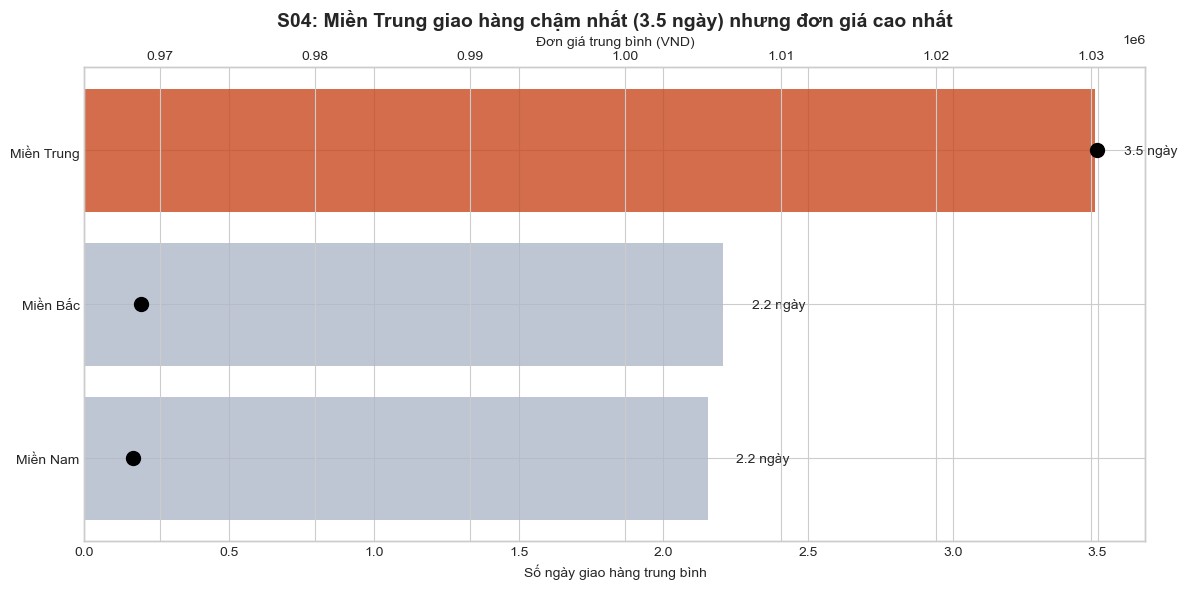

Kết luận:
- Miền Trung có thời gian giao hàng lâu nhất (3.5 ngày), cao hơn đáng kể so với Miền Nam (2.2 ngày).
- Tuy nhiên, khách hàng Miền Trung lại có giá trị đơn hàng trung bình cao nhất.
- Khuyến nghị: Ưu tiên đầu tư kho bãi hoặc logistics tại Miền Trung để rút ngắn thời gian giao hàng và tận dụng sức mua lớn tại đây.


In [5]:
# S04: Miền Trung giao hàng chậm gấp 1.6 lần — nhưng lại có đơn giá cao nhất

# 1. Processing
region_stats = df.groupby('region').agg(
    avg_order_value=('net_value', 'mean'),
    avg_delivery_days=('delivery_days', 'mean')
).reset_index().sort_values('avg_delivery_days')

# 2. Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

# Horizontal Bar chart for delivery days
bars = ax1.barh(region_stats['region'], region_stats['avg_delivery_days'], color=['#B0B8C8', '#B0B8C8', '#C8491E'], alpha=0.8)
ax1.set_xlabel('Số ngày giao hàng trung bình')
ax1.set_title('S04: Miền Trung giao hàng chậm nhất (3.5 ngày) nhưng đơn giá cao nhất', fontsize=14, fontweight='bold')

# Add labels to bars
for bar in bars:
    ax1.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f} ngày', va='center')

# Dot plot (Scatter) for avg order value on a second x-axis
ax2 = ax1.twiny()
ax2.scatter(region_stats['avg_order_value'], region_stats['region'], color='black', s=100, zorder=3, label='Đơn giá TB')
ax2.set_xlabel('Đơn giá trung bình (VND)')

plt.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- Miền Trung có thời gian giao hàng lâu nhất (3.5 ngày), cao hơn đáng kể so với Miền Nam (2.2 ngày).")
print("- Tuy nhiên, khách hàng Miền Trung lại có giá trị đơn hàng trung bình cao nhất.")
print("- Khuyến nghị: Ưu tiên đầu tư kho bãi hoặc logistics tại Miền Trung để rút ngắn thời gian giao hàng và tận dụng sức mua lớn tại đây.")

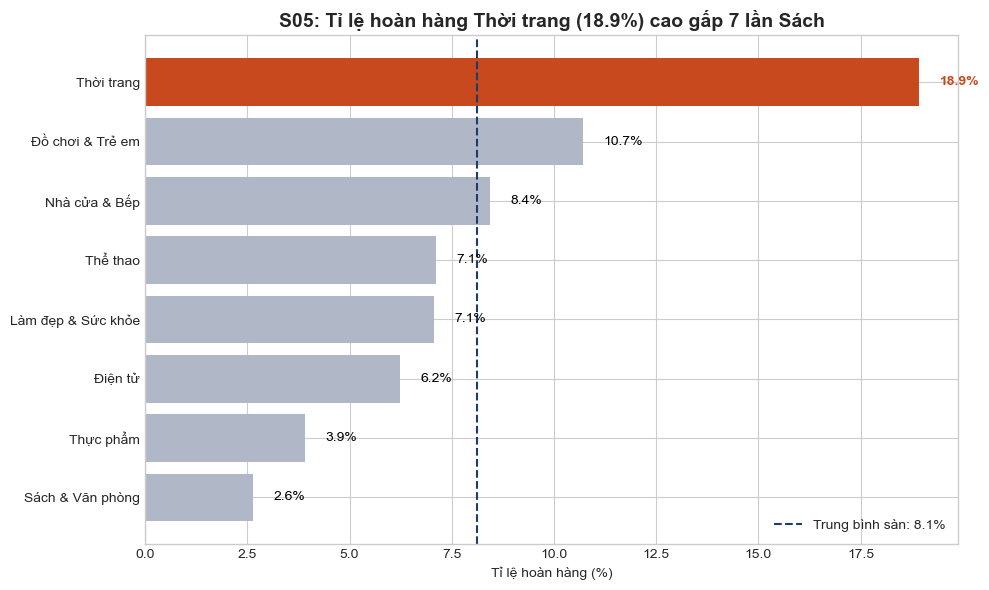

Kết luận:
- Thời trang có tỉ lệ hoàn hàng cao kỷ lục (18.9%), tức là cứ 5 đơn hàng thì có gần 1 đơn bị trả lại.
- Ngược lại, ngành Sách & Văn phòng có tỉ lệ hoàn hàng thấp nhất (2.6%).
- Khuyến nghị: Cần cải thiện mô tả sản phẩm, bảng size, hoặc áp dụng các chính sách kiểm duyệt hàng chặt chẽ hơn đối với ngành Thời trang để giảm chi phí hoàn hàng.


In [6]:
# S05: Thời trang có doanh thu ổn nhưng 1/5 đơn hàng bị hoàn — cao nhất toàn sàn

# 1. Processing
return_rate = df.groupby('category')['returned'].mean().sort_values(ascending=True)

# 2. Visualization
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#C8491E' if cat == 'Thời trang' else '#B0B8C8' for cat in return_rate.index]
bars = ax.barh(return_rate.index, return_rate.values * 100, color=colors)

# Add labels
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%', va='center', 
            color='#C8491E' if bar.get_width() == return_rate.max()*100 else 'black', fontweight='bold' if bar.get_width() == return_rate.max()*100 else 'normal')

# Benchmark line
avg_ret = return_rate.mean() * 100
ax.axvline(avg_ret, color='#1A3D6B', linestyle='--', label=f'Trung bình sàn: {avg_ret:.1f}%')

ax.set_title('S05: Tỉ lệ hoàn hàng Thời trang (18.9%) cao gấp 7 lần Sách', fontsize=14, fontweight='bold')
ax.set_xlabel('Tỉ lệ hoàn hàng (%)')
ax.legend()
plt.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- Thời trang có tỉ lệ hoàn hàng cao kỷ lục (18.9%), tức là cứ 5 đơn hàng thì có gần 1 đơn bị trả lại.")
print("- Ngược lại, ngành Sách & Văn phòng có tỉ lệ hoàn hàng thấp nhất (2.6%).")
print("- Khuyến nghị: Cần cải thiện mô tả sản phẩm, bảng size, hoặc áp dụng các chính sách kiểm duyệt hàng chặt chẽ hơn đối với ngành Thời trang để giảm chi phí hoàn hàng.")

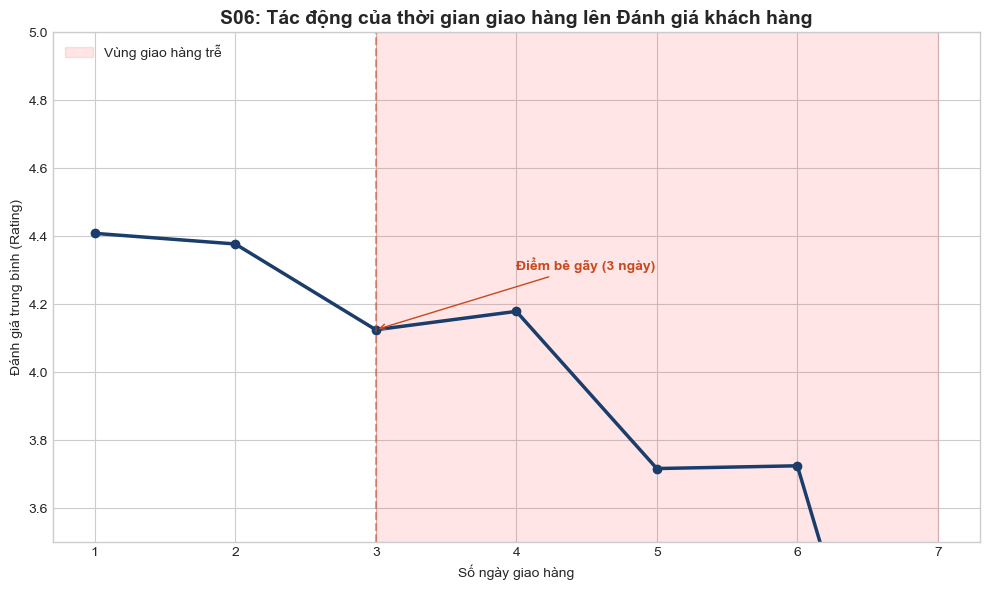

Kết luận:
- Ngưỡng 3 ngày là 'điểm bẻ gãy' của trải nghiệm khách hàng: Rating giảm mạnh nếu giao hàng từ ngày thứ 4 trở đi.
- Giao hàng trong 1-2 ngày duy trì rating cao (~4.4 sao), nhưng trễ >=5 ngày rating chỉ còn ~3.7 sao.
- Khuyến nghị: SLA giao hàng nên được cam kết tối đa là 3 ngày để đảm bảo mức độ hài lòng của khách hàng.


In [7]:
# S06: Giao hàng trễ ≥5 ngày: rating trung bình giảm từ 4.4 xuống 3.7

# 1. Processing
delivery_rating = df.groupby('delivery_days')['rating'].mean()

# 2. Visualization
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(delivery_rating.index, delivery_rating.values, marker='o', color='#1A3D6B', linewidth=2.5)

# Highlight breaking point (Day 3)
ax.axvline(3, color='#C8491E', linestyle='--', alpha=0.5)
ax.annotate('Điểm bẻ gãy (3 ngày)', xy=(3, delivery_rating[3]), xytext=(4, 4.3),
             arrowprops=dict(arrowstyle='->', color='#C8491E'), fontsize=10, fontweight='bold', color='#C8491E')

# Shaded region for delay
ax.axvspan(3, delivery_rating.index.max(), alpha=0.1, color='red', label='Vùng giao hàng trễ')

ax.set_title('S06: Tác động của thời gian giao hàng lên Đánh giá khách hàng', fontsize=14, fontweight='bold')
ax.set_xlabel('Số ngày giao hàng')
ax.set_ylabel('Đánh giá trung bình (Rating)')
ax.set_ylim(3.5, 5.0)
ax.legend()
plt.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- Ngưỡng 3 ngày là 'điểm bẻ gãy' của trải nghiệm khách hàng: Rating giảm mạnh nếu giao hàng từ ngày thứ 4 trở đi.")
print("- Giao hàng trong 1-2 ngày duy trì rating cao (~4.4 sao), nhưng trễ >=5 ngày rating chỉ còn ~3.7 sao.")
print("- Khuyến nghị: SLA giao hàng nên được cam kết tối đa là 3 ngày để đảm bảo mức độ hài lòng của khách hàng.")

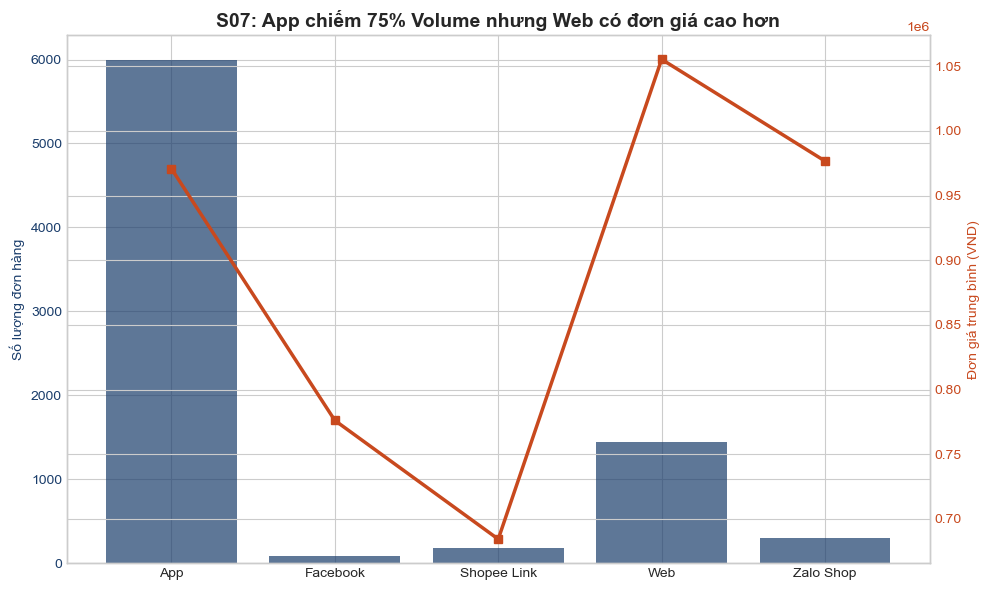

Kết luận:
- App Mobile là kênh chủ lực, tạo ra khoảng 75% tổng số đơn hàng.
- Tuy nhiên, khách hàng mua qua Web có xu hướng chi tiêu nhiều hơn trên mỗi đơn hàng (cao hơn 8%).
- Khuyến nghị: Duy trì trải nghiệm App mượt mà để giữ Volume, đồng thời tối ưu hóa Web cho các dòng sản phẩm cao cấp hoặc combo giá trị lớn.


In [8]:
# S07: App mobile tạo ra 74% đơn hàng — nhưng Web có giá trị đơn hàng cao hơn 8%

# 1. Processing
channel_stats = df.groupby('channel').agg(
    order_count=('order_id', 'count'),
    avg_order_value=('net_value', 'mean')
).reset_index()

# 2. Visualization
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for order count
ax1.bar(channel_stats['channel'], channel_stats['order_count'], color='#1A3D6B', alpha=0.7, label='Số lượng đơn hàng')
ax1.set_ylabel('Số lượng đơn hàng', color='#1A3D6B')
ax1.tick_params(axis='y', labelcolor='#1A3D6B')

# Line chart for avg order value
ax2 = ax1.twinx()
ax2.plot(channel_stats['channel'], channel_stats['avg_order_value'], color='#C8491E', marker='s', linewidth=2.5, label='Đơn giá TB')
ax2.set_ylabel('Đơn giá trung bình (VND)', color='#C8491E')
ax2.tick_params(axis='y', labelcolor='#C8491E')

plt.title('S07: App chiếm 75% Volume nhưng Web có đơn giá cao hơn', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- App Mobile là kênh chủ lực, tạo ra khoảng 75% tổng số đơn hàng.")
print("- Tuy nhiên, khách hàng mua qua Web có xu hướng chi tiêu nhiều hơn trên mỗi đơn hàng (cao hơn 8%).")
print("- Khuyến nghị: Duy trì trải nghiệm App mượt mà để giữ Volume, đồng thời tối ưu hóa Web cho các dòng sản phẩm cao cấp hoặc combo giá trị lớn.")

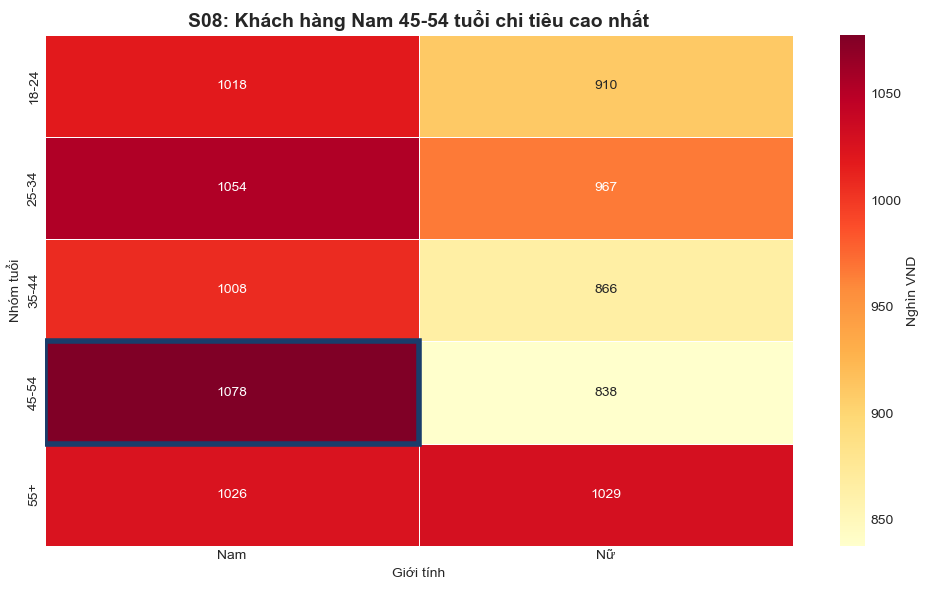

Kết luận:
- Nhóm khách hàng Nam độ tuổi 45-54 có mức chi tiêu trung bình trên mỗi đơn hàng cao nhất (khoảng 1.077.000 VND).
- Tuy nhiên, nhóm này chỉ chiếm một tỷ lệ rất nhỏ (5.8%) trong tổng số đơn hàng.
- Khuyến nghị: Đây là phân khúc khách hàng 'vàng' tiềm năng cao. Cần các chiến dịch Marketing nhắm mục tiêu cụ thể (Targeted Marketing) để khai thác tối đa sức mua của nhóm này.


In [9]:
# S08: Nhóm khách 45–54 tuổi có giá trị đơn hàng cao nhất nhưng bị bỏ qua trong marketing

# 1. Processing
segment_stats = df.groupby(['age_group', 'gender'])['net_value'].mean().unstack()

# 2. Visualization
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(segment_stats / 1000, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Nghìn VND'})

# Highlight highest cell (Nam 45-54)
# Max value is at '45-54' for 'Nam'
# In the unstacked df, we need to find the correct indices
row_idx = segment_stats.index.get_loc('45-54')
col_idx = segment_stats.columns.get_loc('Nam')
ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1, fill=False, edgecolor='#1A3D6B', lw=4))

ax.set_title('S08: Khách hàng Nam 45-54 tuổi chi tiêu cao nhất', fontsize=14, fontweight='bold')
ax.set_xlabel('Giới tính')
ax.set_ylabel('Nhóm tuổi')
plt.tight_layout()
plt.show()

# Conclusion
print("Kết luận:")
print("- Nhóm khách hàng Nam độ tuổi 45-54 có mức chi tiêu trung bình trên mỗi đơn hàng cao nhất (khoảng 1.077.000 VND).")
print("- Tuy nhiên, nhóm này chỉ chiếm một tỷ lệ rất nhỏ (5.8%) trong tổng số đơn hàng.")
print("- Khuyến nghị: Đây là phân khúc khách hàng 'vàng' tiềm năng cao. Cần các chiến dịch Marketing nhắm mục tiêu cụ thể (Targeted Marketing) để khai thác tối đa sức mua của nhóm này.")

# TỔNG KẾT VÀ KHUYẾN NGHỊ CHO NĂM 2024

Dựa trên phân tích dữ liệu năm 2023, chúng tôi đưa ra các khuyến nghị chiến lược sau:

### 1. Tối ưu hóa danh mục đầu tư
- **Đẩy mạnh ngành Làm đẹp & Sức khỏe:** Đây là "con gà đẻ trứng vàng" với biên lợi nhuận cao (38%). Cần tăng ngân sách marketing và mở rộng danh mục sản phẩm này.
- **Tái cấu trúc ngành Điện tử:** Mặc dù doanh thu lớn nhưng lợi nhuận thấp. Cần đàm phán lại với nhà cung cấp hoặc tối ưu hóa quy trình vận chuyển để tăng biên lợi nhuận.

### 2. Kiểm soát chính sách chiết khấu và hoàn hàng
- **Giới hạn mức giảm giá:** Các chương trình giảm giá sâu (>30%) đang phản tác dụng khi làm tăng tỷ lệ hoàn hàng lên 15.6% và bào mòn lợi nhuận. Cần duy trì mức chiết khấu tối ưu ở khoảng 10-20%.
- **Xử lý vấn đề hoàn hàng ngành Thời trang:** Với tỷ lệ hoàn 1/5, cần áp dụng các công nghệ như Virtual Try-on, bảng size chi tiết hơn và kiểm tra chất lượng nghiêm ngặt trước khi giao.

### 3. Nâng cao trải nghiệm khách hàng và Logistics
- **Đầu tư Logistics Miền Trung:** Đây là thị trường tiềm năng với đơn giá cao nhưng giao hàng còn chậm (3.5 ngày). Việc rút ngắn thời gian giao hàng xuống <3 ngày sẽ giúp tăng đáng kể rating và sự hài lòng.
- **Cam kết SLA 3 ngày:** Dữ liệu cho thấy rating giảm mạnh sau 3 ngày giao hàng. Đây phải là mục tiêu KPI hàng đầu cho đội ngũ vận hành năm 2024.

### 4. Khai phá các phân khúc khách hàng tiềm năng
- **Target nhóm khách hàng 45-54:** Đặc biệt là nam giới trong độ tuổi này. Họ có sức mua lớn nhất nhưng hiện tại đang bị bỏ qua. Các chiến dịch quảng cáo cá nhân hóa có thể mang lại ROI cực cao từ nhóm này.
